<a href="https://colab.research.google.com/github/Noelsip/ouroboros3d-model-simple/blob/main/Ouroboros3D_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ouroboros3D — Pipeline (Dataset Multi-View)

Implementasi paper **"Ouroboros3D: Image-to-3D Generation via 3D-aware Recursive Diffusion"** (CVPR 2025).

Alur: **clone repo → siapkan dataset SHREC 2026 → konversi → training → visualisasi & testing**.
Sumber data: **SHREC 2026** (multi-view + pose kamera COLMAP nyata). Hasil konversi ditulis ke `data/real`.

Konsep 3D tetap dipertahankan (recursive 3D-aware: render Gaussian → feedback), tapi
karena tidak terhubung ke Blender, **output yang ditampilkan = kumpulan multi-view image**
+ plot 3D Gaussian sebagai bukti konsep (bukan ekspor mesh 3D).

File `.py` (otomatis ter-clone di cell `[0]`):
- `prepare_shrec.py` — konversi SHREC (pose COLMAP nyata, mask siluet) — *self-contained*
- `dataset.py` / `model.py` / `train.py` — loader, arsitektur, training

## 1. Setup

In [1]:
# [0] Clone repository program — jalankan PALING AWAL
# Mengganti flow lama (upload ouroboros3d_project.zip). Semua file .py
# (dataset, model, train, prepare_shrec) langsung ditarik dari GitHub.
import os

REPO   = "https://github.com/Noelsip/ouroboros3d-model-simple.git"
BRANCH = "main"

# clone bersih ke folder sementara
!rm -rf /content/_repo
!git clone --depth 1 --branch {BRANCH} {REPO} /content/_repo

# salin file program ke working dir (/content) supaya import & path relatif tetap jalan
!cp /content/_repo/*.py /content/ 2>/dev/null
!cp /content/_repo/requirements.txt /content/ 2>/dev/null

print("\nFile program siap:")
!ls /content/*.py /content/requirements.txt 2>/dev/null

Cloning into '/content/_repo'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 30.15 KiB | 3.01 MiB/s, done.

File program siap:
/content/dataset.py  /content/prepare_objaverse.py  /content/requirements.txt
/content/model.py    /content/prepare_shrec.py	    /content/train.py


In [2]:
!nvidia-smi || echo "No GPU — akan jalan di CPU"

Tue Jun 16 16:15:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Dependencies
!pip install torch torchvision numpy matplotlib tqdm -q
!pip install "rembg[cpu]" -q
!pip install lpips -q
# rembg sering mengacak versi Pillow di Colab (error "_Ink" / PIL._typing rusak).
# Pasang ulang Pillow KONSISTEN setelah rembg:
!pip install -q --force-reinstall "pillow"

import importlib.util
has_rembg = importlib.util.find_spec("rembg") is not None
has_ort   = importlib.util.find_spec("onnxruntime") is not None
has_lpips = importlib.util.find_spec("lpips") is not None
print(f"\nrembg={has_rembg}, onnxruntime={has_ort}, lpips={has_lpips}")
print("\n" + "=" * 60)
print(">>> WAJIB SEKALI: menu Runtime -> Restart session <<<")
print(">>> lalu jalankan ulang mulai dari cell [0].          <<<")
print(">>> (biar Pillow yang benar termuat; abaikan warning RAPIDS) <<<")
print("=" * 60)

## 2. Sumber Dataset — SHREC 2026

Dataset **SHREC 2026** (Reconstruction of High-Frequency Geometry): 938 objek heritage,
**90 view/objek**, dengan **pose kamera COLMAP nyata** (intrinsics + extrinsics).
Pose nyata → generator bisa belajar geometri (hasil 3D tidak blur).

Hasil konversi ditulis ke `data/real`, lalu lanjut ke cell `[3]`–`[8]` (sanity, training,
loss, visualisasi, metrik).

1. `[S1]` Download dari Kaggle + **inspeksi struktur folder** (pohon direktori).
2. `[S2]` Konversi (`prepare_shrec.py`): pose COLMAP → `camera_poses`, mask siluet (rembg).

### Langkah dataset SHREC

Jalankan `[S1]` (download + inspeksi struktur) lalu `[S2]` (konversi).
**Penting:** lihat dulu output pohon folder di `[S1]` untuk memastikan tiap objek terpisah
(gambar + pose-nya sendiri) sebelum konversi — supaya tiap `object_XXX` berisi multi-view
dari **satu** objek yang sama, bukan campuran objek.

In [4]:
# [S1] Download SHREC 2026 dari Kaggle + inspeksi struktur folder
# Ambil token: kaggle.com -> Settings -> API -> Create New Token (unduh kaggle.json)
from google.colab import files
print("Pilih kaggle.json...")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle datasets download -d cristianllull/shrec-2026-retrieval-of-high-frequency-geometry \
    -p data/shrec --unzip

# === INSPEKSI STRUKTUR (WAJIB dibaca sebelum [S2]) ===
# Tujuan: tahu PERSIS bagaimana 1 objek dipisah (folder gambar + file pose COLMAP-nya).
# Tempel output di bawah ini supaya konversi [S2] / prepare_shrec.py bisa disesuaikan.
import os

ROOT = "data/shrec"

def tree(path, prefix="", depth=0, max_depth=4, max_entries=8):
    if depth > max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except (NotADirectoryError, PermissionError):
        return
    shown = entries[:max_entries]
    for i, name in enumerate(shown):
        full = os.path.join(path, name)
        last = (i == len(shown) - 1) and (len(entries) <= max_entries)
        conn = "└─ " if last else "├─ "
        tag = "/" if os.path.isdir(full) else ""
        print(f"{prefix}{conn}{name}{tag}")
        if os.path.isdir(full):
            tree(full, prefix + ("   " if last else "│  "), depth + 1, max_depth, max_entries)
    if len(entries) > max_entries:
        print(f"{prefix}└─ ... (+{len(entries) - max_entries} lagi)")

print(f"\n=== POHON FOLDER: {ROOT} (maks 4 level) ===")
tree(ROOT)

# Cari di mana file pose COLMAP / NeRF berada
import glob
print("\n=== FILE POSE yang ditemukan ===")
for pat in ("images.txt", "cameras.txt", "transforms*.json"):
    hits = glob.glob(os.path.join(ROOT, "**", pat), recursive=True)
    print(f"  {pat}: {len(hits)} file" + (f"  contoh: {hits[0]}" if hits else ""))

# Hitung berapa PNG per folder (deteksi: 1 objek = 90 view di SATU folder?)
print("\n=== JUMLAH PNG per folder (top 10 folder terbanyak) ===")
counts = {}
for p in glob.glob(os.path.join(ROOT, "**", "*.png"), recursive=True):
    counts[os.path.dirname(p)] = counts.get(os.path.dirname(p), 0) + 1
for d, c in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    print(f"  {c:4d}  {d}")
print(f"\nTotal folder berisi PNG: {len(counts)} | total PNG: {sum(counts.values())}")

Pilih kaggle.json...


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/cristianllull/shrec-2026-retrieval-of-high-frequency-geometry
License(s): apache-2.0
100% 17.2G/17.2G [03:33<00:00, 86.5MB/s]


=== POHON FOLDER: data/shrec (maks 4 level) ===
├─ All_faces_sculpted_derivatives/
│  ├─ 90_1920x1080_relief_heightmap_10_all_cone.obj/
│  │  ├─ camera_data.json
│  │  ├─ colmap/
│  │  │  ├─ cameras.txt
│  │  │  ├─ images.txt
│  │  │  └─ points3D.txt
│  │  ├─ frame_001.png
│  │  ├─ frame_002.png
│  │  ├─ frame_003.png
│  │  ├─ frame_004.png
│  │  ├─ frame_005.png
│  │  ├─ frame_006.png
│  │  └─ ... (+84 lagi)
│  ├─ 90_1920x1080_relief_heightmap_10_all_cylinder.obj/
│  │  ├─ camera_data.json
│  │  ├─ colmap/
│  │  │  ├─ cameras.txt
│  │  │  ├─ images.txt
│  │  │  └─ points3D.txt
│  │  ├─ frame_001.png
│  │  ├─ frame_002.png
│  │  ├─ frame_003.png
│  │  ├─ frame_004.png
│  │  ├─ frame_005.png
│  │  ├─ frame_006.png
│  │  └─ ... (+84 lagi)
│  ├─ 90_1920x1080_relief_heightmap_10_all_egg

In [10]:
# [S2] Konversi SHREC -> data/real (pose COLMAP -> camera_poses, + mask rembg)
# Discovery anti-campur: tiap object_XXX = beberapa SUDUT dari SATU objek yang sama.
# --max-objects 500 : pakai 500 objek (dari 938) -> cukup utk model belajar, hemat ruang/waktu
# --num-views 16    : subsample 16 sudut dari 90 view per objek
!python prepare_shrec.py --input data/shrec --output data/real \
    --num-views 8 --max-objects 60 --mask-method rembg

# Perhatikan output "object_000 <- <folder> (contoh view: ...)":
# pastikan tiap objek sumbernya 1 folder (tidak campur). Lalu LANJUT ke cell [3].
# Catatan: training (cell [3]) auto-deteksi num_views=16.

Ditemukan 528 folder objek (tiap objek terpisah).
Objek terpakai: 60 (num_views=8)
Menyiapkan rembg (U2Net)...
Konversi SHREC:   0% 0/60 [00:00<?, ?objek/s]  object_000  <-  data/shrec/All_faces_sculpted_derivatives/90_1920x1080_relief_heightmap_10_all_cone.obj  (contoh view: ['frame_001.png', 'frame_014.png', 'frame_026.png'])
Konversi SHREC:   2% 1/60 [00:10<09:55, 10.10s/objek]  object_001  <-  data/shrec/All_faces_sculpted_derivatives/90_1920x1080_relief_heightmap_10_all_cylinder.obj  (contoh view: ['frame_001.png', 'frame_014.png', 'frame_026.png'])
Konversi SHREC:   2% 1/60 [00:15<15:42, 15.97s/objek]
Traceback (most recent call last):
  File "/content/prepare_shrec.py", line 367, in <module>
    main()
  File "/content/prepare_shrec.py", line 348, in main
    rgb, mask = segment_rembg(im, session)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/prepare_shrec.py", line 99, in segment_rembg
    out = remove(im.convert("RGB"), session=session)
          ^^^^^^^^^^^^^^^^

num_views terdeteksi: 8
Train batches: 25 | Val batches: 5


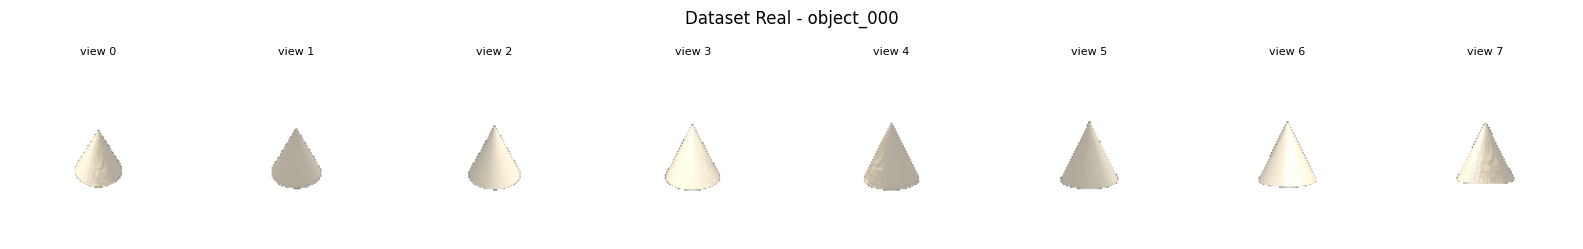

In [8]:
import glob
from PIL import Image
import matplotlib.pyplot as plt
from dataset import build_dataloaders

# deteksi num_views dari objek pertama
# n_views = len(glob.glob("data/real/object_000/views/view_*.png"))
# Explicitly set n_views to 8, as data was prepared with --num-views 8
n_views = 8
print(f"num_views terdeteksi: {n_views}")

tr, va = build_dataloaders("data/real", img_size=64, num_views=n_views,
                           batch_size=2, num_workers=0)
print(f"Train batches: {len(tr)} | Val batches: {len(va)}")

# preview objek pertama
fig, axes = plt.subplots(1, n_views, figsize=(2*n_views, 2.4))
axes = [axes] if n_views == 1 else axes
for i in range(n_views):
    axes[i].imshow(Image.open(f"data/real/object_000/views/view_{i:02d}.png"))
    axes[i].set_title(f"view {i}", fontsize=8); axes[i].axis("off")
plt.suptitle("Dataset Real - object_000", y=1.02); plt.tight_layout(); plt.show()

In [11]:
# [4] Training pakai dataset real
# num_views otomatis ikut cell [3]. batch-size kecil supaya aman utk dataset kecil.
# --w-ccm 0    : matikan loss CCM (tak ada geometri GT, CCM placeholder nol)
# --w-mask 0.5 : aktifkan loss siluet (alpha vs mask foreground) -> bentuk 3D tersupervisi
!python train.py --data-root data/real --num-views {n_views} --epochs 75 --batch-size 4 \
    --img-size 64 --num-gaussians 128 --use-feedback --joint --w-ccm 0 --w-mask 0.5 --tag real

Device: cuda
Config: use_feedback=True, joint=True, tag=real

[1/4] Dataloaders...
  train=12 batch, val=3 batch

[2/4] Building Ouroboros3D model...
  params: 7,522,595 (7.52M)
    - mv_generator : 4.24M
    - reconstructor: 3.28M

[3/4] Training for 75 epoch(s)...
Epoch 1/75 | train: mv=0.801 rnd=0.052 ccm=0.000 msk=0.137 tot=0.895 | val: mv=0.408 rnd=0.046 ccm=0.000 msk=0.090 tot=0.476 | 8.2s
Epoch 2/75 | train: mv=0.326 rnd=0.048 ccm=0.000 msk=0.127 tot=0.413 | val: mv=0.257 rnd=0.043 ccm=0.000 msk=0.085 tot=0.321 | 16.3s
Epoch 3/75 | train: mv=0.220 rnd=0.044 ccm=0.000 msk=0.115 tot=0.300 | val: mv=0.182 rnd=0.040 ccm=0.000 msk=0.079 tot=0.241 | 24.2s
Epoch 4/75 | train: mv=0.157 rnd=0.039 ccm=0.000 msk=0.102 tot=0.228 | val: mv=0.131 rnd=0.032 ccm=0.000 msk=0.072 tot=0.183 | 31.7s
Epoch 5/75 | train: mv=0.115 rnd=0.030 ccm=0.000 msk=0.093 tot=0.177 | val: mv=0.094 rnd=0.029 ccm=0.000 msk=0.070 tot=0.144 | 39.9s
Epoch 6/75 | train: mv=0.085 rnd=0.029 ccm=0.000 msk=0.083 tot=0.141 

In [ ]:
# [4b] Loss curve training real
import torch
import matplotlib.pyplot as plt

h = torch.load("checkpoints/ouroboros_real.pt", map_location="cpu", weights_only=False)["history"]
ep = [x["epoch"] for x in h]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, yscale, title in [(axes[0], "linear", "Skala linear"), (axes[1], "log", "Skala log (lebih kebaca)")]:
    ax.plot(ep, [x["train"]["total"] for x in h], "b-",  label="train total", linewidth=1.8)
    ax.plot(ep, [x["val"]["total"]   for x in h], "r--", label="val total",   linewidth=1.8)
    ax.plot(ep, [x["train"]["mv"]    for x in h], "g-",  label="train mv (RGB)", linewidth=1.2)
    ax.plot(ep, [x["train"]["mask"]  for x in h], "m-",  label="train mask (siluet)", linewidth=1.2)
    ax.set_yscale(yscale)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

plt.suptitle("Training Curve — Dataset Real")
plt.tight_layout()
plt.show()

### Visualisasi & Testing — Dataset Real

Load checkpoint `ouroboros_real.pt`, jalankan inferensi pada objek validasi dari dataset Drive-mu, lalu tampilkan:
- **RGB**: target GT vs prediksi multi-view vs render 3D Gaussian Splatting
- **Siluet**: alpha (prediksi) vs mask (GT) — bukti geometri tersupervisi
- **3D Gaussians** + metrik kuantitatif (L1 / PSNR, step-1 vs step-2).

In [13]:
# [5] Load model hasil training real + inferensi
import torch
from dataset import build_dataloaders
from model import Ouroboros3D

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_r = torch.load("checkpoints/ouroboros_real.pt", map_location=device, weights_only=False)
cfg = ckpt_r["args"]          # ambil config persis seperti saat training
model_r = Ouroboros3D(
    num_views=cfg["num_views"], base_ch=cfg.get("base_ch", 32),
    num_gaussians=cfg["num_gaussians"],
    img_size=cfg["img_size"], use_feedback=cfg["use_feedback"],
).to(device)
model_r.load_state_dict(ckpt_r["model_state"])
model_r.eval()

_, val_loader_r = build_dataloaders(
    "data/real", img_size=cfg["img_size"], num_views=cfg["num_views"],
    batch_size=1, num_workers=0,
)
batch_r = next(iter(val_loader_r))
cond_r  = batch_r["cond_image"].to(device)
poses_r = batch_r["poses"].to(device)

with torch.no_grad():
    outs_r = model_r(cond_r, poses_r, num_recursive_steps=2)

print(f"Model real loaded (img_size={cfg['img_size']}, num_views={cfg['num_views']}, "
      f"gaussians={cfg['num_gaussians']}, base_ch={cfg.get('base_ch', 32)}). Inferensi selesai.")

Model real loaded (img_size=64, num_views=8, gaussians=128, base_ch=32). Inferensi selesai.


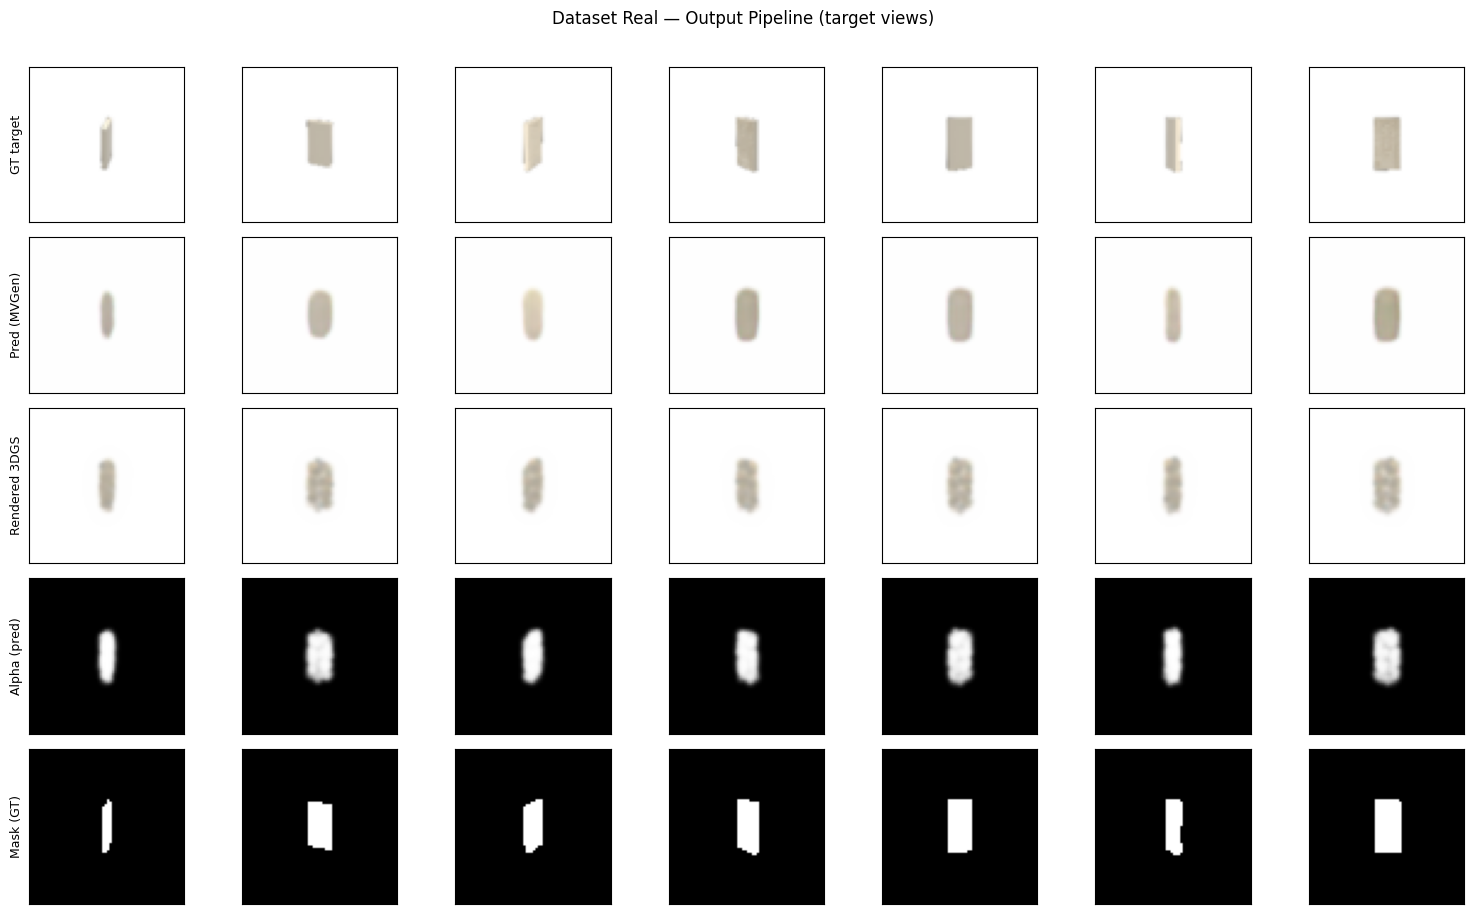

In [14]:
# [6] Grid prediksi multi-view: RGB + siluet (alpha vs mask)
import numpy as np
import matplotlib.pyplot as plt

def denorm(t):
    return (t.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)

o = outs_r[-1]
pred    = o["pred_target"][0].cpu()        # [N-1, 3, H, W]
gt      = batch_r["target_rgb"][0]         # [N-1, 3, H, W]
rend    = o["rendered_rgb"][0].cpu()       # [N, 3, H, W]
alpha   = o["alpha"][0, :, 0].cpu()        # [N, H, W]
gt_mask = batch_r["all_mask"][0, :, 0]     # [N, H, W]

nv = pred.shape[0]   # jumlah target view (N-1)
rows = ["GT target", "Pred (MVGen)", "Rendered 3DGS", "Alpha (pred)", "Mask (GT)"]

fig, axes = plt.subplots(5, nv, figsize=(2.2 * nv, 9), squeeze=False)
for i in range(nv):
    axes[0, i].imshow(denorm(gt[i]))
    axes[1, i].imshow(denorm(pred[i]))
    axes[2, i].imshow(denorm(rend[i + 1]))           # +1: index 0 = conditioning
    axes[3, i].imshow(alpha[i + 1].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[4, i].imshow(gt_mask[i + 1].numpy(), cmap="gray", vmin=0, vmax=1)
    for r in range(5):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
for r, label in enumerate(rows):
    axes[r, 0].set_ylabel(label, fontsize=9)

plt.suptitle("Dataset Real — Output Pipeline (target views)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

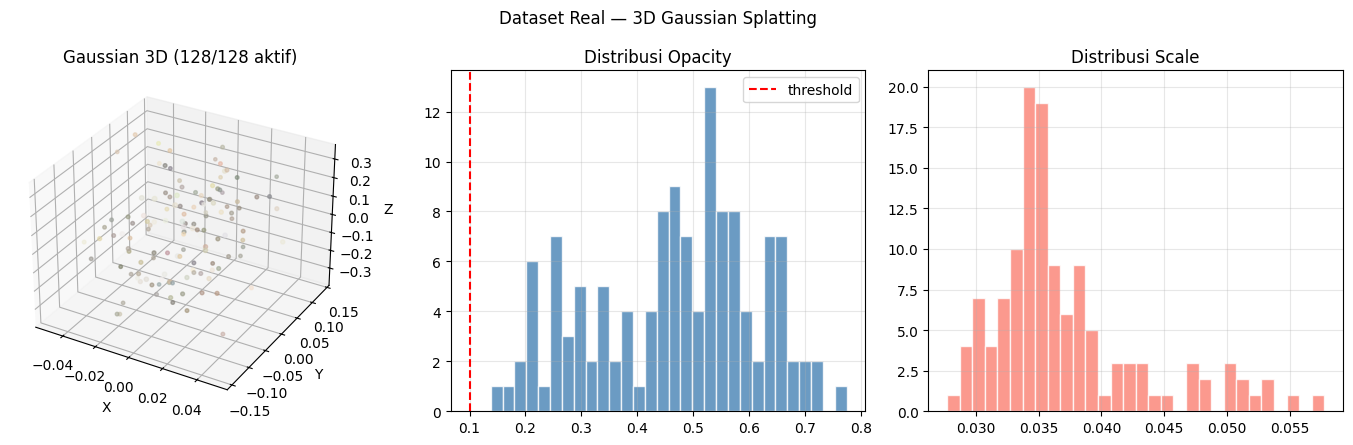

In [15]:
# [7] Visualisasi 3D Gaussians hasil rekonstruksi objek real
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

g = outs_r[-1]["gaussians"]
pos   = g["pos"][0].cpu().numpy()
rgb   = g["rgb"][0].cpu().numpy()
opa   = g["opacity"][0, :, 0].cpu().numpy()
scale = g["scale"][0, :, 0].cpu().numpy()
keep  = opa > 0.1

fig = plt.figure(figsize=(14, 4.5))
ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(pos[keep, 0], pos[keep, 1], pos[keep, 2],
            c=rgb[keep].clip(0, 1), s=scale[keep] * 200, alpha=0.6)
ax1.set_title(f"Gaussian 3D ({keep.sum()}/{len(keep)} aktif)")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

ax2 = fig.add_subplot(132)
ax2.hist(opa, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(0.1, color="red", linestyle="--", label="threshold")
ax2.set_title("Distribusi Opacity"); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(133)
ax3.hist(scale, bins=30, color="salmon", edgecolor="white", alpha=0.8)
ax3.set_title("Distribusi Scale"); ax3.grid(True, alpha=0.3)

plt.suptitle("Dataset Real — 3D Gaussian Splatting", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# [8] Testing kuantitatif pada seluruh objek validasi
# Metrik: L1, PSNR, SSIM, LPIPS (sama seperti Tab. 1 paper) + IoU siluet (tambahan kita)
import numpy as np
import torch
import torch.nn.functional as F

try:
    import lpips
    _lpips_fn = lpips.LPIPS(net="alex").to(device).eval()
    HAS_LPIPS = True
except ImportError:
    HAS_LPIPS = False
    print("Paket 'lpips' tidak ditemukan -> jalankan: !pip install lpips -q lalu restart runtime.")


def psnr_from_mse(mse):
    return 10.0 * np.log10(1.0 / (mse + 1e-8))


def ssim_simple(img1, img2, window_size=11, C1=0.01 ** 2, C2=0.03 ** 2):
    """SSIM single-scale (Gaussian window), img1/img2: [B,3,H,W] range [0,1]."""
    channel = img1.shape[1]
    sigma = 1.5
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).to(img1.device)
    window = (g[:, None] @ g[None, :]).unsqueeze(0).unsqueeze(0)
    window = window.expand(channel, 1, window_size, window_size)

    pad = window_size // 2
    mu1 = F.conv2d(img1, window, padding=pad, groups=channel)
    mu2 = F.conv2d(img2, window, padding=pad, groups=channel)
    mu1_sq, mu2_sq, mu1_mu2 = mu1 * mu1, mu2 * mu2, mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=pad, groups=channel) - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean().item()


l1_s1, l1_s2, psnr_s1, ssim_s1, lpips_s1, iou = [], [], [], [], [], []
model_r.eval()
with torch.no_grad():
    for b in val_loader_r:
        c = b["cond_image"].to(device)
        p = b["poses"].to(device)
        gt   = b["target_rgb"]                 # [1, N-1, 3, H, W]
        gtm  = b["all_mask"].to(device)        # [1, N, 1, H, W]

        outs = model_r(c, p, num_recursive_steps=2)
        pr1 = outs[0]["pred_target"].cpu()
        pr2 = outs[-1]["pred_target"].cpu()

        l1_s1.append((pr1 - gt).abs().mean().item())
        l1_s2.append((pr2 - gt).abs().mean().item())
        mse = ((pr1 * 0.5 + 0.5) - (gt * 0.5 + 0.5)).pow(2).mean().item()
        psnr_s1.append(psnr_from_mse(mse))

        # SSIM di range [0, 1], dihitung per-view lalu dirata-rata
        pr1_01 = (pr1[0] * 0.5 + 0.5).clamp(0, 1)   # [N-1, 3, H, W]
        gt_01  = (gt[0]  * 0.5 + 0.5).clamp(0, 1)
        ssim_s1.append(ssim_simple(pr1_01, gt_01))

        # LPIPS di range [-1, 1] (sesuai normalisasi dataset, tidak perlu denorm)
        if HAS_LPIPS:
            d = _lpips_fn(pr1[0].to(device), gt[0].to(device))
            lpips_s1.append(d.mean().item())

        # IoU siluet: alpha (pred) vs mask (GT)
        a = (outs[-1]["alpha"] > 0.5).float()
        m = (gtm > 0.5).float()
        inter = (a * m).sum().item()
        union = ((a + m) > 0).float().sum().item()
        iou.append(inter / (union + 1e-8))

print("=" * 50)
print(f"  Objek validasi   : {len(l1_s1)}")
print(f"  L1    (step-1)   : {np.mean(l1_s1):.4f}")
print(f"  L1    (step-2)   : {np.mean(l1_s2):.4f}")
print(f"  PSNR  (step-1)   : {np.mean(psnr_s1):.2f} dB")
print(f"  SSIM  (step-1)   : {np.mean(ssim_s1):.4f}")
if HAS_LPIPS:
    print(f"  LPIPS (step-1)   : {np.mean(lpips_s1):.4f}")
print(f"  IoU siluet       : {np.mean(iou):.3f}")
print("=" * 50)
if np.mean(l1_s2) < np.mean(l1_s1):
    imp = (np.mean(l1_s1) - np.mean(l1_s2)) / np.mean(l1_s1) * 100
    print(f"  Recursive feedback membantu: step-2 lebih baik {imp:.1f}%")
else:
    print("  Step-1 & step-2 setara (model belum converged penuh / epoch sedikit).")

# Simpan untuk tabel perbandingan dengan paper di cell berikutnya
OUR_METRICS = {
    "psnr": float(np.mean(psnr_s1)),
    "ssim": float(np.mean(ssim_s1)),
    "lpips": float(np.mean(lpips_s1)) if HAS_LPIPS and len(lpips_s1) > 0 else None,
    "l1_step1": float(np.mean(l1_s1)),
    "l1_step2": float(np.mean(l1_s2)),
    "iou": float(np.mean(iou)),
    "n_val": len(l1_s1),
}

## 9. Perbandingan dengan Paper Ouroboros3D

Membandingkan **proses training** dan **metrik evaluasi (PSNR/SSIM/LPIPS)** hasil project
ini dengan angka yang dilaporkan paper asli (Tab. 1, Tab. 2, Tab. 4), lalu menjelaskan
kenapa angkanya berbeda jauh.

In [ ]:
# [9] Tabel perbandingan: Paper (Tab. 1/2/4) vs Project (hasil run ini)
n_steps_ours = len(h) * len(tr)  # epoch x train-batch/epoch

print("=" * 78)
print("A. PERBANDINGAN PROSES TRAINING")
print("=" * 78)
rows_train = [
    ("Data training",   "~80,000 objek (Objaverse, synthetic)", f"{60} objek (SHREC 2026, real heritage)"),
    ("Resolusi",         "512x512, 8 frame/sample",              f"{cfg['img_size']}x{cfg['img_size']}, {cfg['num_views']} view"),
    ("Hardware",         "8x A100 GPU",                          "1x GPU Colab (T4 pada run notebook ini)"),
    ("Batch size",       "32",                                   f"{4}"),
    ("Iterasi/step",     "30,000 iterasi",                       f"~{n_steps_ours} step ({len(h)} epoch x {len(tr)} batch)"),
    ("Loss generator",   "L1 + LPIPS (perceptual)",              "L1 + 0.5*L2 (mv) + L1 (render) + BCE (mask), tanpa LPIPS"),
    ("CCM supervision",  "CCM asli dari render synthetic",       "placeholder nol (w_ccm=0), diganti loss mask siluet"),
    ("Train loss total", "tidak dilaporkan kurva training",      f"{h[0]['train']['total']:.4f} -> {h[-1]['train']['total']:.4f} ({(h[0]['train']['total']-h[-1]['train']['total'])/h[0]['train']['total']*100:.1f}%)"),
]
for name, paper_v, our_v in rows_train:
    print(f"  {name:16s} | paper: {paper_v:42s} | kita: {our_v}")

print()
print("=" * 78)
print("B. PERBANDINGAN METRIK EVALUASI (Tab. 1, kolom 3D)")
print("=" * 78)
paper_3d = {"PSNR": 21.761, "SSIM": 0.8894, "LPIPS": 0.1091}
rows_metric = [
    ("PSNR (dB)",  f"{paper_3d['PSNR']:.2f}",  f"{OUR_METRICS['psnr']:.2f}"),
    ("SSIM",       f"{paper_3d['SSIM']:.4f}",  f"{OUR_METRICS['ssim']:.4f}"),
    ("LPIPS",      f"{paper_3d['LPIPS']:.4f}", f"{OUR_METRICS['lpips']:.4f}" if OUR_METRICS["lpips"] is not None else "N/A"),
    ("L1",         "tidak dilaporkan",          f"{OUR_METRICS['l1_step1']:.4f} (step-1) / {OUR_METRICS['l1_step2']:.4f} (step-2)"),
    ("IoU siluet", "tidak dilaporkan",          f"{OUR_METRICS['iou']:.3f}"),
    ("#Objek eval","100 (GSO, di luar distribusi training)", f"{OUR_METRICS['n_val']} (SHREC, dalam distribusi training)"),
]
for name, paper_v, our_v in rows_metric:
    print(f"  {name:11s} | paper: {paper_v:40s} | kita: {our_v}")

print()
print("=" * 78)
print("C. EFEK 3D-AWARE FEEDBACK (step tanpa feedback vs dengan feedback)")
print("=" * 78)
imp = (OUR_METRICS['l1_step1'] - OUR_METRICS['l1_step2']) / OUR_METRICS['l1_step1'] * 100
print(f"  paper (Tab. 2): PSNR naik 20.012 -> 21.761 dB saat full feedback ditambah (+8.7%)")
print(f"  kita          : L1 turun {OUR_METRICS['l1_step1']:.4f} -> {OUR_METRICS['l1_step2']:.4f} step1->step2 ({imp:.1f}%)")
print("  -> arah hasil SAMA (feedback membantu), besarannya beda jauh (lihat penjelasan di bawah).")

### Kenapa angkanya berbeda jauh? (terutama PSNR jauh lebih tinggi dari paper)

1. **Resolusi jauh lebih rendah** (64x64 vs 512x512 di paper). PSNR sangat sensitif ke
   resolusi/detail frekuensi tinggi — makin sedikit detail yang harus ditebak, makin mudah
   skor PSNR tinggi, padahal informasi yang direkonstruksi jauh lebih sedikit.
2. **Validation set "mudah" karena homogen & dekat dengan distribusi training.** 9 objek
   validasi berasal dari subset yang sama (60 objek relief SHREC, gaya geometris mirip:
   heightmap relief, cone, sphere, dst). Paper menguji di **GSO — 100 objek rumah tangga
   yang sama sekali tidak pernah dilihat model**, lintas kategori sangat beragam. Ini
   perbandingan "interpolasi dalam domain sempit" vs "generalisasi zero-shot lintas domain".
3. **Tidak ada proses diffusion/stokastik.** Generator paper adalah video diffusion model —
   outputnya lebih sharp/detail tapi karena itu lebih "berani" menebak tekstur, sehingga
   rawan dihukum PSNR meski perseptual lebih realistis (makanya paper juga melaporkan
   LPIPS/SSIM, bukan cuma PSNR). Model kita regresi deterministik feed-forward → cenderung
   menghasilkan output yang lebih halus/aman, yang menguntungkan skor PSNR tapi bukan
   kualitas visual sebenarnya.
4. **Loss = metrik evaluasi yang sama (L1).** Model kita dioptimasi langsung dengan L1, dan
   dievaluasi pakai L1/PSNR juga — tidak ada perceptual loss (LPIPS) yang menambah
   tantangan seperti di paper (Eq. 2: $L_{rgb} + \lambda L_{LPIPS}$). Ini membuat angka
   evaluasi "selaras" dengan objektif training, bukan tes generalisasi independen.
5. **Skala data 80,000 vs 60 objek.** Model paper harus mampu menggeneralisasi ke ribuan
   bentuk berbeda; model kita cukup menangkap variasi kecil dalam satu dataset heritage
   yang sempit — tugasnya jauh lebih mudah secara definisi.
6. **Kenapa peningkatan dari feedback (step-1 -> step-2) jauh lebih kecil** dibanding paper:
   paper memakai hingga 25 langkah recursive denoising, sehingga feedback CCM+RGB menutup
   hampir seluruh gap (Tab. 2: ΔPSNR turun dari 1.067 -> 0.009). Project ini hanya 2
   recursive step (`--train-steps 2`), kapasitas model kecil (`base_ch=32`,
   `num_gaussians=128`), dan task sudah "mudah" sejak step-1 — jadi ruang untuk feedback
   menunjukkan perbaikan besar memang tidak banyak tersisa. Arahnya tetap konsisten dengan
   paper (feedback membantu), hanya besarannya jauh lebih kecil.

**Ringkasnya:** angka mentah project ini "lebih bagus" di PSNR, tapi itu artefak dari
resolusi rendah + dataset sempit + evaluasi pada split yang masih dekat distribusi training
— bukan bukti model lebih superior dari Ouroboros3D asli. Tren kualitatif (feedback
membantu, joint training membantu, CCM+RGB feedback lebih baik dari salah satu saja)
tetap konsisten dengan temuan paper.

## 10. Ablation Study (replikasi Tabel 2 Paper)

Paper mengablasi 3 komponen: **Joint Training**, **CCM Feedback**, **RGB Feedback** (5 kombinasi),
lalu melaporkan PSNR/SSIM/LPIPS dari hasil 3DGS + **ΔPSNR/ΔSSIM/ΔLPIPS** (selisih absolut antara
kualitas multi-view generation vs kualitas 3D — mengukur seberapa besar gap konsistensi antar 2 stage).

Implementasi awal kita menggabungkan RGB+CCM feedback jadi satu (`--use-feedback`), jadi tidak bisa
mengisolasi CCM-only / RGB-only. `model.py`/`train.py` sudah diupdate dengan flag terpisah
`--use-rgb-feedback` dan `--use-ccm-feedback` supaya 5 baris ini bisa dilatih persis seperti paper:

| # | Joint | CCM FB | RGB FB | Command flag tambahan | Tag |
|---|---|---|---|---|---|
| 1 | ✗ | ✗ | ✗ | *(tidak ada)* | `ablation_baseline` |
| 2 | ✓ | ✗ | ✗ | `--joint` | `ablation_joint` |
| 3 | ✓ | ✓ | ✗ | `--joint --use-ccm-feedback` | `ablation_ccm` |
| 4 | ✓ | ✗ | ✓ | `--joint --use-rgb-feedback` | `ablation_rgb` |
| 5 | ✓ | ✓ | ✓ | `--joint --use-feedback` | `real` (sudah dilatih di cell `[4]`) |

Jalankan 4 cell training baru di bawah (`[10a]`-`[10d]`), lalu cell `[10e]` akan memuat ke-5
checkpoint dan menyusun tabel evaluasi.

In [ ]:
# [10a] Ablasi 1/5 - baseline (tanpa joint, tanpa feedback sama sekali)
!python train.py --data-root data/real --num-views {n_views} --epochs 75 --batch-size 4 \
    --img-size 64 --num-gaussians 128 --w-ccm 0 --w-mask 0.5 --tag ablation_baseline

In [ ]:
# [10b] Ablasi 2/5 - joint training saja (tanpa feedback)
!python train.py --data-root data/real --num-views {n_views} --epochs 75 --batch-size 4 \
    --img-size 64 --num-gaussians 128 --joint --w-ccm 0 --w-mask 0.5 --tag ablation_joint

In [ ]:
# [10c] Ablasi 3/5 - joint + CCM feedback saja (tanpa RGB feedback)
!python train.py --data-root data/real --num-views {n_views} --epochs 75 --batch-size 4 \
    --img-size 64 --num-gaussians 128 --joint --use-ccm-feedback \
    --w-ccm 0 --w-mask 0.5 --tag ablation_ccm

In [ ]:
# [10d] Ablasi 4/5 - joint + RGB feedback saja (tanpa CCM feedback)
!python train.py --data-root data/real --num-views {n_views} --epochs 75 --batch-size 4 \
    --img-size 64 --num-gaussians 128 --joint --use-rgb-feedback \
    --w-ccm 0 --w-mask 0.5 --tag ablation_rgb

# Ablasi 5/5 (Joint+CCM+RGB) = model "full" yang sudah dilatih di cell [4] -> checkpoints/ouroboros_real.pt

In [ ]:
# [10e] Evaluasi 5 konfigurasi ablasi -> tabel format Tabel 2 paper
# (pakai ssim_simple / psnr_from_mse / _lpips_fn / HAS_LPIPS yang sudah didefinisikan di cell [8])
import numpy as np
import torch
from dataset import build_dataloaders
from model import Ouroboros3D

ABLATION_TAGS = ["ablation_baseline", "ablation_joint", "ablation_ccm", "ablation_rgb", "real"]


def eval_checkpoint(tag):
    ckpt = torch.load(f"checkpoints/ouroboros_{tag}.pt", map_location=device, weights_only=False)
    c = ckpt["args"]
    joint   = bool(c.get("joint", False))
    use_rgb = bool(c.get("use_rgb_feedback", False))
    use_ccm = bool(c.get("use_ccm_feedback", False))

    m = Ouroboros3D(
        num_views=c["num_views"], base_ch=c.get("base_ch", 32),
        num_gaussians=c["num_gaussians"], img_size=c["img_size"],
        use_rgb_feedback=use_rgb, use_ccm_feedback=use_ccm,
    ).to(device)
    m.load_state_dict(ckpt["model_state"])
    m.eval()

    _, vl = build_dataloaders("data/real", img_size=c["img_size"], num_views=c["num_views"],
                               batch_size=1, num_workers=0)

    mv_psnr, mv_ssim, mv_lpips = [], [], []
    td_psnr, td_ssim, td_lpips = [], [], []
    n_steps = 2 if (use_rgb or use_ccm) else 1
    with torch.no_grad():
        for b in vl:
            cnd = b["cond_image"].to(device)
            p   = b["poses"].to(device)
            gt_target = b["target_rgb"]          # [1, N-1, 3, H, W]  (utk stage MV)
            gt_all    = b["all_rgb"]             # [1, N,   3, H, W]  (utk stage 3D)

            outs = m(cnd, p, num_recursive_steps=n_steps)
            o = outs[-1]
            pred = o["pred_target"].cpu()        # stage MV (generator)
            rend = o["rendered_rgb"].cpu()       # stage 3D (render dari Gaussian)

            mse_mv = ((pred * 0.5 + 0.5) - (gt_target * 0.5 + 0.5)).pow(2).mean().item()
            mv_psnr.append(psnr_from_mse(mse_mv))
            mv_ssim.append(ssim_simple((pred[0] * 0.5 + 0.5).clamp(0, 1), (gt_target[0] * 0.5 + 0.5).clamp(0, 1)))
            if HAS_LPIPS:
                mv_lpips.append(_lpips_fn(pred[0].to(device), gt_target[0].to(device)).mean().item())

            mse_3d = ((rend * 0.5 + 0.5) - (gt_all * 0.5 + 0.5)).pow(2).mean().item()
            td_psnr.append(psnr_from_mse(mse_3d))
            td_ssim.append(ssim_simple((rend[0] * 0.5 + 0.5).clamp(0, 1), (gt_all[0] * 0.5 + 0.5).clamp(0, 1)))
            if HAS_LPIPS:
                td_lpips.append(_lpips_fn(rend[0].to(device), gt_all[0].to(device)).mean().item())

    return {
        "joint": joint, "ccm": use_ccm, "rgb": use_rgb,
        "psnr": np.mean(td_psnr), "ssim": np.mean(td_ssim),
        "lpips": np.mean(td_lpips) if HAS_LPIPS else None,
        "d_psnr": abs(np.mean(mv_psnr) - np.mean(td_psnr)),
        "d_ssim": abs(np.mean(mv_ssim) - np.mean(td_ssim)),
        "d_lpips": abs(np.mean(mv_lpips) - np.mean(td_lpips)) if HAS_LPIPS else None,
    }


def mark(b):
    return "✓" if b else "✗"   # checkmark / cross, sama seperti Tabel 2 paper


header = (f"{'Joint':6s}{'CCM FB':9s}{'RGB FB':9s}"
          f"{'PSNR↑':>9s}{'SSIM↑':>9s}{'LPIPS↓':>9s}"
          f"{'dPSNR↓':>9s}{'dSSIM↓':>9s}{'dLPIPS↓':>9s}")
print("=" * len(header))
print("TABEL ABLASI - PROJECT KITA (format sama dengan Tabel 2 paper)")
print("=" * len(header))
print(header)

our_rows = []
for tag in ABLATION_TAGS:
    try:
        r = eval_checkpoint(tag)
    except FileNotFoundError:
        print(f"  [skip] checkpoints/ouroboros_{tag}.pt belum ada -> jalankan cell [10a]-[10d] dulu.")
        continue
    lp  = f"{r['lpips']:.4f}"   if r["lpips"]   is not None else "N/A"
    dlp = f"{r['d_lpips']:.4f}" if r["d_lpips"] is not None else "N/A"
    print(f"{mark(r['joint']):6s}{mark(r['ccm']):9s}{mark(r['rgb']):9s}"
          f"{r['psnr']:9.3f}{r['ssim']:9.4f}{lp:>9s}{r['d_psnr']:9.3f}{r['d_ssim']:9.4f}{dlp:>9s}")
    our_rows.append((tag, r))

print()
print("=" * len(header))
print("TABEL 2 PAPER (referensi, dataset Objaverse 80K + GSO benchmark)")
print("=" * len(header))
print(header)
paper_rows = [
    ("x", "x", "x", 20.012, 0.8465, 0.1287, 1.067, 0.0125, 0.0189),
    ("v", "x", "x", 20.549, 0.8651, 0.1183, 0.511, 0.0094, 0.0070),
    ("v", "v", "x", 21.325, 0.8937, 0.1092, 0.304, 0.0036, 0.0018),
    ("v", "x", "v", 21.542, 0.8871, 0.1103, 0.100, 0.0101, 0.0036),
    ("v", "v", "v", 21.761, 0.9094, 0.0991, 0.009, 0.0028, 0.0002),
]
for j, c_, r_, psnr, ssim, lpips_v, dp, ds, dl in paper_rows:
    j  = mark(j == "v"); c_ = mark(c_ == "v"); r_ = mark(r_ == "v")
    print(f"{j:6s}{c_:9s}{r_:9s}{psnr:9.3f}{ssim:9.4f}{lpips_v:9.4f}{dp:9.3f}{ds:9.4f}{dl:9.4f}")